# Validating the reconstruction

The public crash file stopped updating on **2026-06-11**. TrafficStat kept
publishing. This notebook establishes whether TrafficStat can stand in for the
missing period, by comparing the two over the months they both cover.

Run `python src/collect.py all` first if `data/raw/` is empty.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd

import reconstruct
import trafficstat as ts
from constants import DATA_PROCESSED, DATA_RAW, FREEZE_DATE

pd.set_option("display.width", 120)

## 1. The gap

The premise. Re-check it every session — if the file has been unfrozen, the framing changes.

In [2]:
so = pd.read_csv(DATA_RAW / "socrata_crashes_2026.csv")
so["dt"] = pd.to_datetime(so.crash_date)

tsdf = pd.read_csv(DATA_RAW / "trafficstat_ytd_collisions.csv")
tsdf["dt"] = pd.to_datetime(tsdf.timestamp, format="%m/%d/%y %I%p", errors="coerce")

print(f"Socrata newest crash:   {so.dt.max():%Y-%m-%d}")
print(f"TrafficStat as of:      {ts.as_of()}")
print(f"Gap:                    {(tsdf.dt > FREEZE_DATE).sum():,} collisions")

Socrata newest crash:   2026-06-11
TrafficStat as of:      09/13/26
Gap:                    20,625 collisions


## 2. Do the two sources agree where both are live?

This is the whole question. If they diverge over Jan–June, nothing reconstructed
for July–September can be trusted.

In [3]:
reconstruct.validate()

Overlap 2026-01-01 .. 2026-06-11 (both sources live)
  Socrata:      36,424
  TrafficStat:  36,839
  ratio:         1.011

         socrata  trafficstat  ratio
dt                                  
2026-01   6773.0         6739  0.995
2026-02   6492.0         6497  1.001
2026-03   6759.0         6730  0.996
2026-04   6665.0         6630  0.995
2026-05   7413.0         7331  0.989
2026-06   2322.0         7361  3.170
2026-07      NaN         6848    NaN
2026-08      NaN         6800    NaN
2026-09      NaN         2528    NaN


,socrata,trafficstat,ratio
dt,,,
2026-01,6773.0,6739,0.995
2026-02,6492.0,6497,1.001
2026-03,6759.0,6730,0.996
2026-04,6665.0,6630,0.995
2026-05,7413.0,7331,0.989
2026-06,2322.0,7361,3.170
2026-07,NaN,6848,NaN
2026-08,NaN,6800,NaN
2026-09,NaN,2528,NaN


Within ±1.1% every month. The June ratio is meaningless — Socrata's June is
truncated at the 11th.

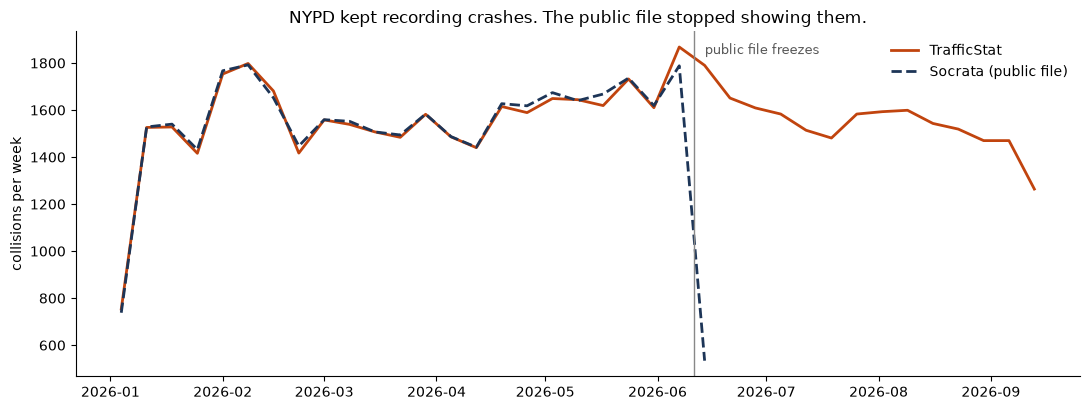

In [4]:
cut = pd.Timestamp(FREEZE_DATE)
weekly_so = so[so.dt <= cut].groupby(pd.Grouper(key="dt", freq="W")).size()
weekly_ts = tsdf.groupby(pd.Grouper(key="dt", freq="W")).size()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(weekly_ts.index, weekly_ts.values, lw=2, color="#c1440e", label="TrafficStat")
ax.plot(weekly_so.index, weekly_so.values, lw=2, ls="--", color="#1d3557", label="Socrata (public file)")
ax.axvline(cut, color="#888", lw=1)
ax.annotate("public file freezes", xy=(cut, ax.get_ylim()[1]*0.95),
            xytext=(8, 0), textcoords="offset points", fontsize=9, color="#555")
ax.set_ylabel("collisions per week")
ax.set_title("NYPD kept recording crashes. The public file stopped showing them.")
ax.legend(frameon=False)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()

## 3. An independent check

Hoodline reported on 2026-09-10 that NYPD had logged **54,832** crashes through
August 30, against 36,195 visible in the public file. That figure came from an
entirely separate route, so agreement is real corroboration rather than
circularity.

In [5]:
thru = tsdf[tsdf.dt <= "2026-08-30"]
print(f"TrafficStat through 08/30: {len(thru):,}   (reported: 54,832)")
print(f"Socrata visible:           {len(so):,}   (reported: 36,195)")
print(f"difference:                {abs(len(thru)-54832)/54832:.2%}")

TrafficStat through 08/30: 54,730   (reported: 54,832)
Socrata visible:           36,424   (reported: 36,195)
difference:                0.19%


## 4. What the reconstruction contains

Built by `python src/reconstruct.py build`. Columns Socrata carries that cannot
be recovered are present but null — see `research/limitations.md`.

In [6]:
rec = pd.read_csv(DATA_PROCESSED / "reconstructed_crashes_gap.csv")
print(f"{len(rec):,} crashes, {rec.crash_date.min()} .. {rec.crash_date.max()}\n")
pd.DataFrame({
    "non-null": rec.notna().sum(),
    "coverage": (rec.notna().mean() * 100).round(1),
})

20,625 crashes, 2026-06-12 .. 2026-09-13



,non-null,coverage
crash_date,20625,100.0
crash_time,20625,100.0
latitude,20625,100.0
longitude,20625,100.0
on_street_name,20571,99.7
zip_code,20530,99.5
precinct,20625,100.0
collision_type,20625,100.0
roadway_type,20571,99.7
geocode_dist_feet,20625,100.0


In [7]:
rec.head(5)

,crash_date,crash_time,latitude,longitude,on_street_name,zip_code,precinct,collision_type,roadway_type,geocode_dist_feet,...,injured_moped_rider,injured_car_occupant,injured_suv_occupant,number_of_persons_injured,number_of_persons_killed,contributing_factor_vehicle_1,collision_id,cross_street_name,off_street_name,borough
0,2026-09-13,00:00,40.656783,-73.913779,CHURCH AVE,11212.0,73,UNKNOWN,Street,2.777867,...,False,False,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-09-13,00:00,40.657921,-73.901887,SACKMAN ST,11212.0,73,UNKNOWN,Street,0.089268,...,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-09-13,00:00,40.658454,-73.911003,THOMAS S BOYLAND ST,11212.0,73,UNKNOWN,Street,58.934412,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-09-13,00:00,40.668747,-73.917885,PITKIN AVE,11212.0,73,UNKNOWN,Street,40.945112,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-09-12,00:00,40.668988,-73.915428,HERZL ST,11212.0,73,OTHER,Street,0.160140,...,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Where the missing crashes happened

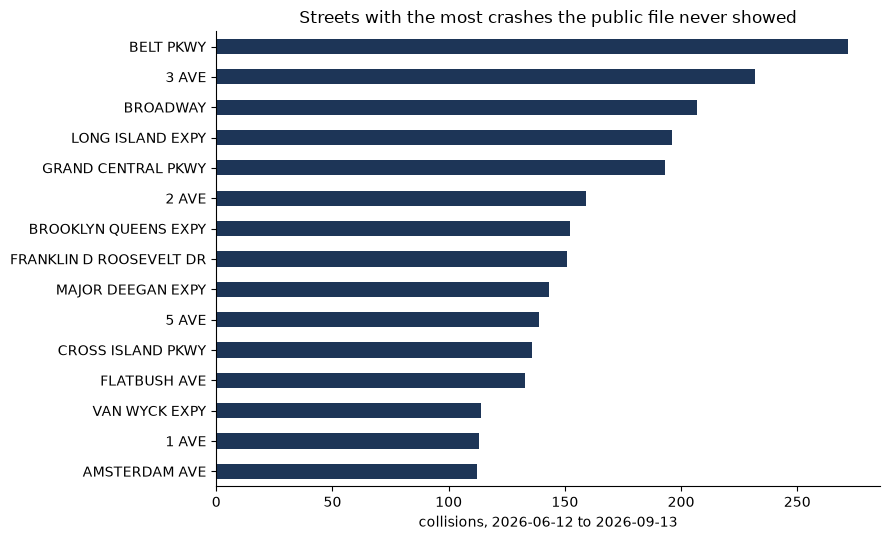

In [8]:
top = rec.on_street_name.value_counts().head(15)
ax = top.sort_values().plot.barh(figsize=(9, 5.5), color="#1d3557")
ax.set_xlabel(f"collisions, {rec.crash_date.min()} to {rec.crash_date.max()}")
ax.set_ylabel("")
ax.set_title("Streets with the most crashes the public file never showed")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()

## 6. Caveats to carry into any writeup

- Coordinates are an **independent geocode**, not Socrata's numbers — a spliced
  series has a discontinuity at 2026-06-11.
- Injury and fatality data are **boolean flags, not counts**.
- Time of day is missing for ~24% (`time_is_known`).
- Street names are *nearest centerline*, 88.2% agreement — good for counting per
  street, not for quoting one crash's location.